# Unemployment Analysis in India using Python

### Internship Project

**Prepared by:** Dipali Khandar

**Domain:** Data Science

**Tools:** Python, Pandas, Matplotlib, Seaborn, NumPy, Google Colab

## 1. Introduction

This project analyzes unemployment trends in India using Python. The objective is to understand unemployment patterns across regions, examine the impact of COVID-19 on employment, identify seasonal trends, and derive insights through exploratory data analysis and visualization techniques.





## 2. Objectives
* Analyze unemployment trends in India.
* Study the impact of COVID-19 on unemployment rates.
* Compare unemployment levels across different regions.
* Identify monthly and seasonal patterns.
* Generate insights useful for economic and social policy decisions.

## 3. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

##  4. Loading Dataset

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

# Corrected file path
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Unemployment in India.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 5. Dataset Overview

In [ ]:
df.shape

(768, 7)

The dataset contains 768 rows and 7 columns, providing information about unemployment trends across different regions of India.

In [ ]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [ ]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

## 6. Dataset Information

The dataset contains:

* Region
* Date
* Frequency
* Estimated Unemployment Rate (%)
* Estimated Employed
* Estimated Labour Participation Rate (%)
* Area (Urban/Rural)

The dataset includes unemployment statistics across various Indian states and regions.


## 7. Data Cleaning

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [ ]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year



>Missing values were identified and removed to ensure accurate analysis. Date values were converted into a suitable format, and additional Month and Year columns were created for trend analysis.



## 8. Exploratory Data Analysis

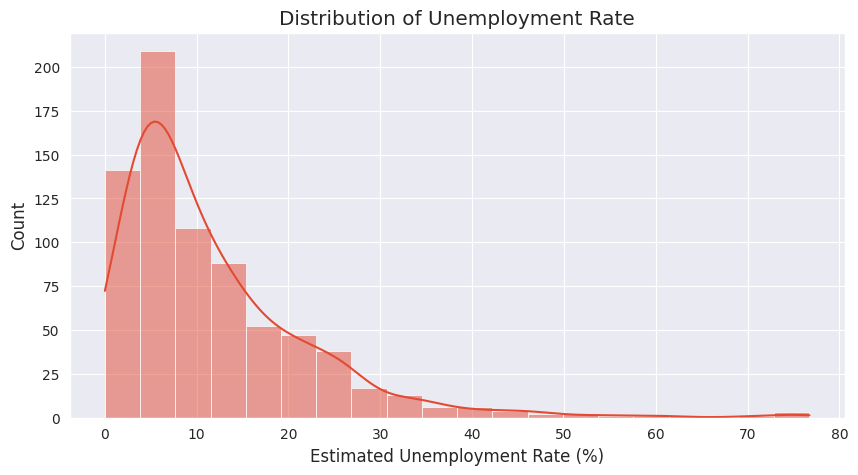

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20, kde=True)
plt.title("Distribution of Unemployment Rate")
plt.show()

Observation

Most unemployment rates are concentrated between 3% and 15%, while a smaller number of observations extend beyond 30%.

Insight

> The distribution is positively skewed, indicating that unemployment remained moderate for most observations but experienced sharp spikes during certain periods, likely due to economic disruptions such as the COVID-19 pandemic.



## 9. State-wise Analysis

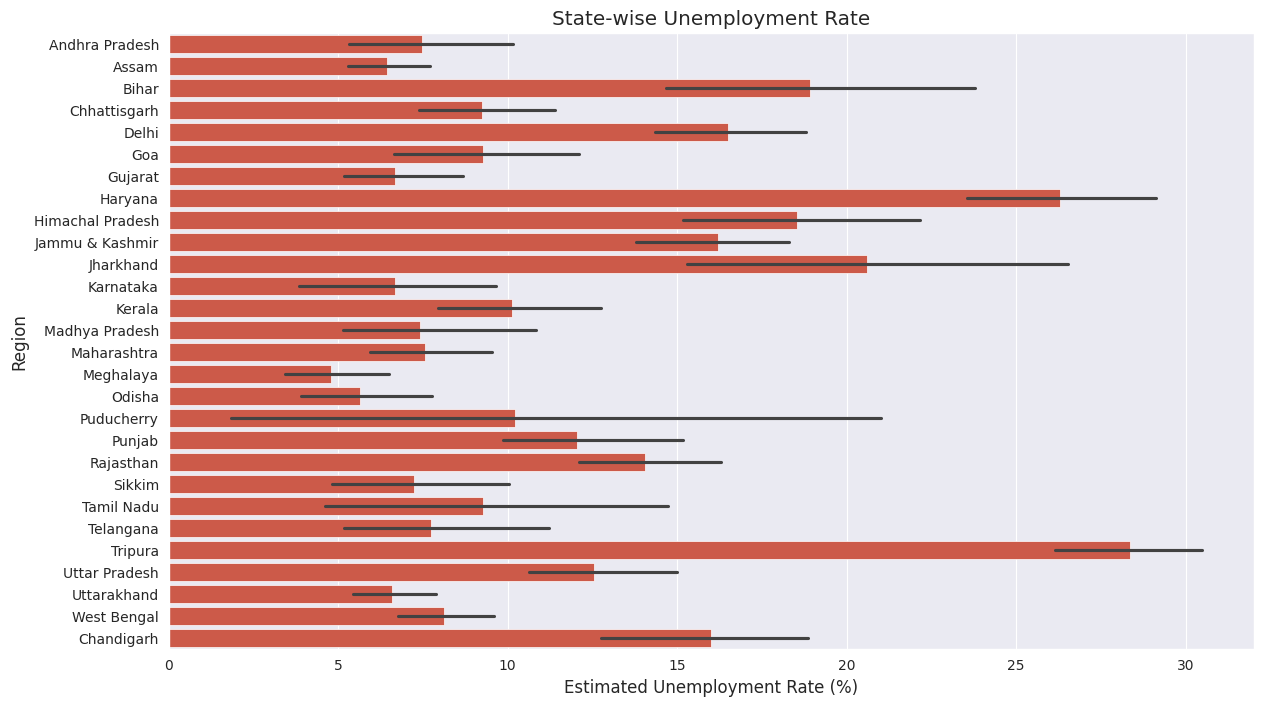

In [ ]:
plt.figure(figsize=(14,8))
sns.barplot(
    x='Estimated Unemployment Rate (%)',
    y='Region',
    data=df
)
plt.title("State-wise Unemployment Rate")
plt.show()

Observation

Significant variation exists among states, with some states recording unemployment rates close to 30%, while others remained below 10%.

Insight
> The variation suggests that employment opportunities and economic conditions differ substantially across regions, highlighting regional disparities in India's labor market.

## 10. Top 10 States by Average Unemployment Rate

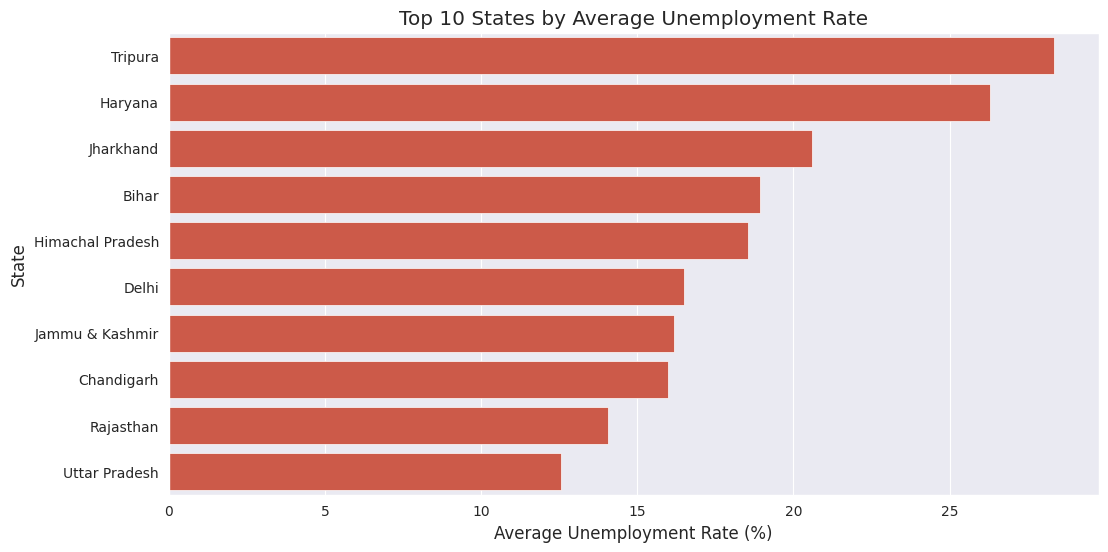

In [ ]:
top_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_states.values, y=top_states.index)

plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

Observation

Tripura recorded the highest average unemployment rate, followed by Haryana and Jharkhand. Uttar Pradesh had the lowest unemployment rate among the top ten states.

Insight
> The consistently higher unemployment levels in these states indicate persistent employment challenges and may require targeted economic and workforce development policies.

## 11. COVID-19 Impact Analysis

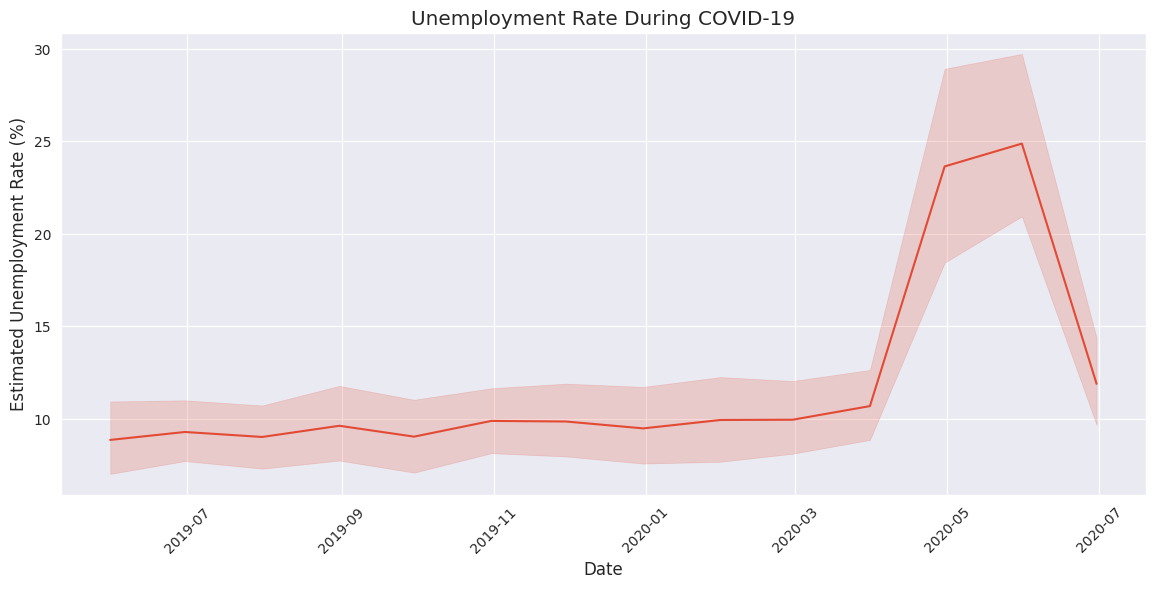

In [ ]:
plt.figure(figsize=(14,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Unemployment Rate During COVID-19")
plt.xticks(rotation=45)
plt.show()

Observation

Unemployment remained relatively stable before 2020 but increased sharply during the COVID-19 period, reaching its highest level around mid-2020 before declining again.

Insight
> The graph clearly demonstrates the severe impact of COVID-19 on employment, with lockdown measures and economic restrictions leading to substantial job losses across the country.

## 12. Seasonal Trend Analysis

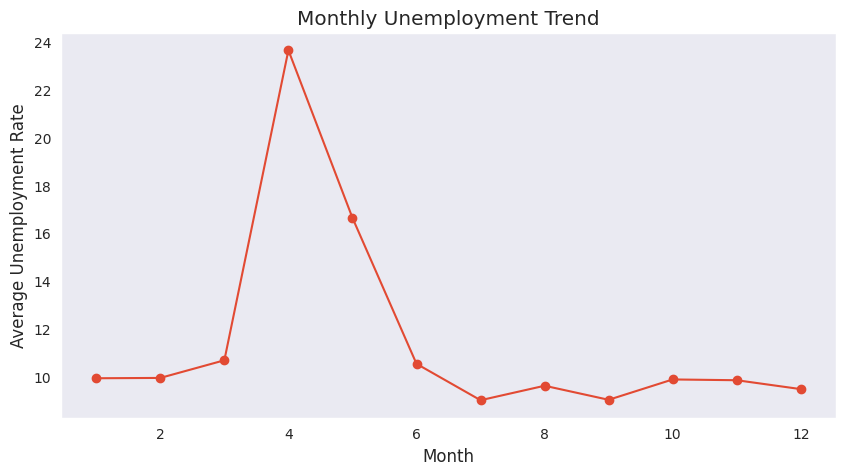

In [ ]:
monthly = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))
monthly.plot(marker='o')

plt.title("Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate")
plt.grid()
plt.show()

Observation

The unemployment rate peaked dramatically in April, reaching approximately 24%, followed by a decline in subsequent months.

Insight
>The sudden spike in April corresponds with the nationwide lockdown period, confirming that COVID-19 had a direct and significant effect on employment levels.

## 13. Rural vs Urban Analysis

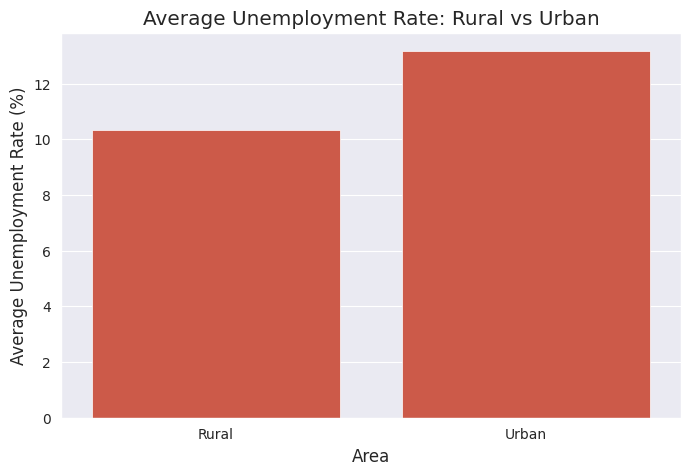

In [ ]:
area_avg = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(8,5))
sns.barplot(
    x=area_avg.index,
    y=area_avg.values
)

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()

Observation

Urban areas recorded a higher average unemployment rate (around 13%) compared to rural areas (around 10%).

Insight
>Urban employment was more heavily affected by economic disruptions, likely because industries, services, and businesses in cities were more vulnerable to lockdown restrictions.

## 14. Correlation Analysis

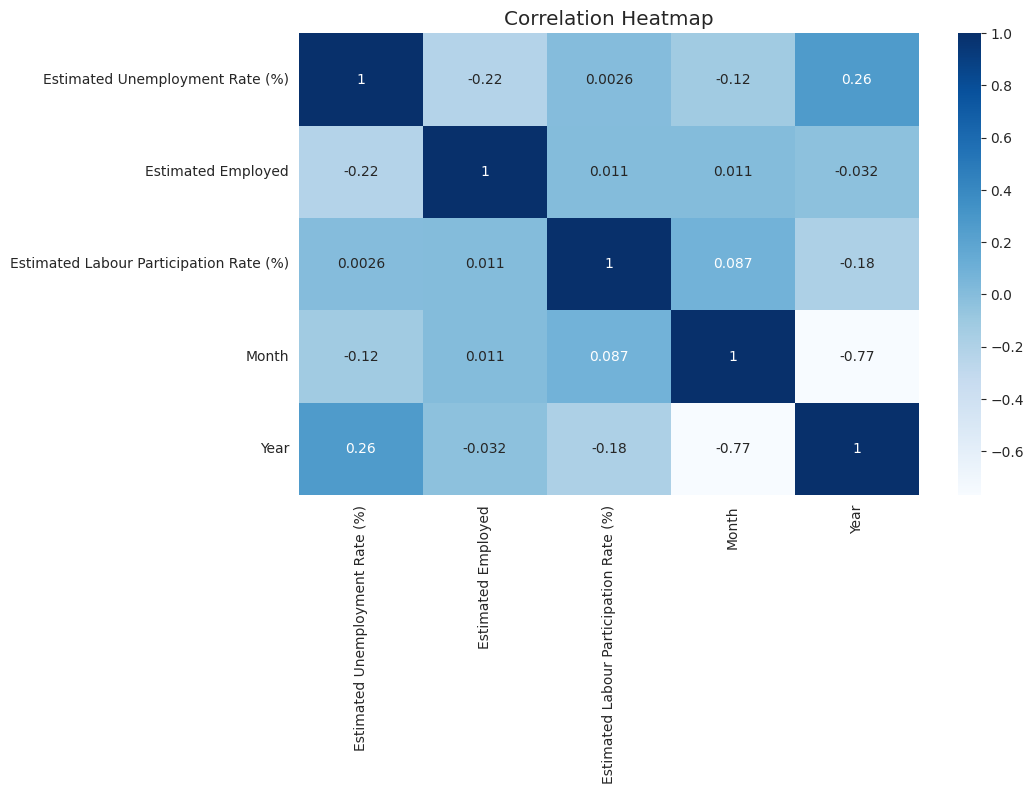

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')

plt.title("Correlation Heatmap")
plt.show()

Observation

A weak negative correlation (-0.22) exists between unemployment rate and estimated employment. The strongest relationship observed is between Month and Year (-0.77).

Insight
>The weak correlations suggest that unemployment is influenced by multiple factors rather than a single variable, highlighting the complexity of labor market dynamics.

## 15. Regional Heatmap Analysis

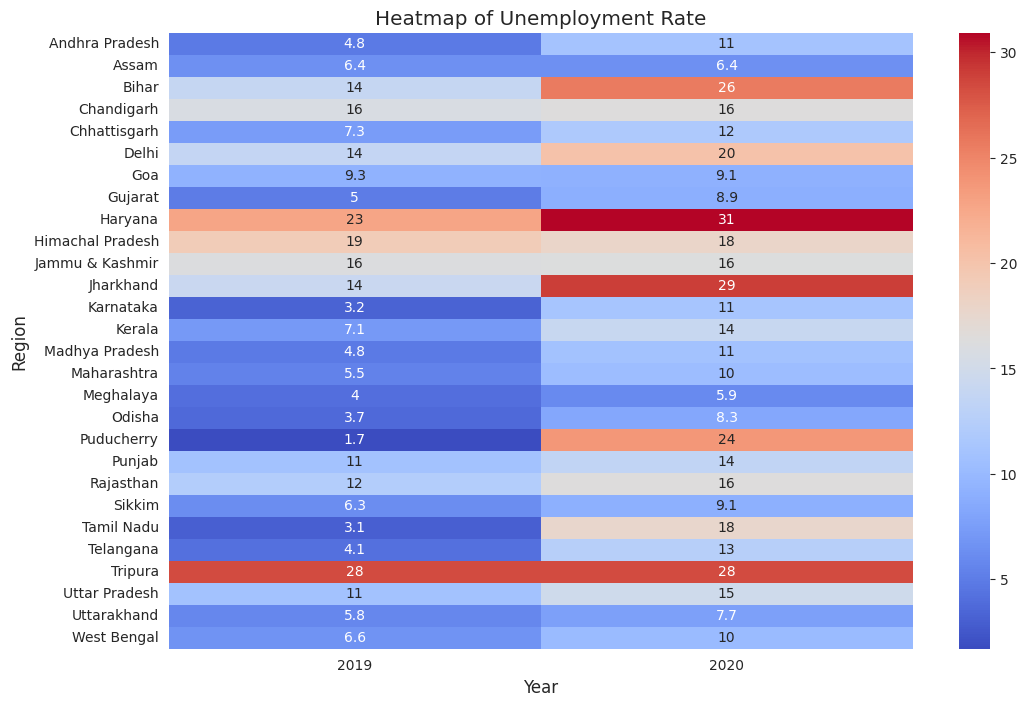

In [ ]:
pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Year'
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='coolwarm', annot=True)

plt.title("Heatmap of Unemployment Rate")
plt.show()

Observation

Most states show noticeably higher unemployment rates in 2020 compared to 2019. States such as Haryana, Jharkhand, and Puducherry experienced particularly large increases.

Insight
>The heatmap confirms that unemployment rose across much of India during 2020, reflecting the widespread economic impact of the COVID-19 pandemic.

## 16. Key Findings:
1. Most unemployment rates were concentrated between 3% and 15%.
2. Considerable variation in unemployment levels exists across Indian states.
3. Tripura, Haryana, and Jharkhand recorded some of the highest average unemployment rates.
4. The COVID-19 pandemic caused a sharp increase in unemployment during 2020.
5. Unemployment peaked in April 2020, coinciding with nationwide lockdown measures.
6. Urban areas experienced higher unemployment rates than rural areas.
7. Most states showed higher unemployment levels in 2020 compared to 2019.
8. Labor market trends are influenced by multiple economic and regional factors.

## 17. Project Summary

This project successfully analyzed unemployment trends in India using exploratory data analysis and visualization techniques. The study highlighted regional differences, COVID-19 impacts, seasonal patterns, and employment disparities across areas.

## 18. Conclusion

This project analyzed unemployment trends in India using Python-based data analysis and visualization techniques. The results revealed significant regional variations in unemployment rates and highlighted the severe impact of the COVID-19 pandemic on employment. A sharp rise in unemployment was observed during the lockdown period, particularly in April 2020. The analysis also showed that urban areas were more affected than rural areas and that several states experienced substantial increases in unemployment during 2020. Overall, the project demonstrates how data analytics can be used to identify labor market trends and support informed economic decision-making.